## Analysis of the simulations output



Analysis of the files obtained in JWST server, using 450 combinations of parameters.

- Tmax = 5000 generations
- Number of replicates = 10000 replicates (one round)
- Size of array = 10 spacers

In [1]:
import glob
import pandas as pd
import re 

def load_file(file_path):
    # Load the data, skipping the first 5 lines
    data = pd.read_csv(file_path, delim_whitespace=True, skiprows=5) 
    return data

# Specify the folder path and file pattern
folder_path = "/Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/OUTPUTS/050325/"
file_pattern = r"OutputFile_*.txt"

# Get a list of all files matching the pattern
file_paths = glob.glob(folder_path + file_pattern)
data_dict = {file_path: load_file(file_path) for file_path in file_paths}

# Verify data
#for file, data in data_dict.items():
#    print(f"Data for {file}:\n", data)

In [2]:
columns = next(iter(data_dict.values())).columns  # Get columns from the first DataFrame(with next and iter)
print(columns)

Index(['beta', 'age', 'efficacy', 'fitness', 'endemicBeta', 'epidemicBeta',
       '(means)'],
      dtype='object')


### Ratio between maxima, position of minimum and FWHM (Full Width at Half Maximum)

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import glob
import numpy as np
import math 
import os

# Linear interpolation to find the index corresponding to the midpoint value
def find_interpolated_index(x_values, y_values, midpoint_value):
    # Perform linear interpolation to find the corresponding index
    for i in range(len(y_values) - 1):
        if (y_values[i] <= midpoint_value <= y_values[i + 1]) or (y_values[i] >= midpoint_value >= y_values[i + 1]):
            x_left = x_values[i]
            x_right = x_values[i + 1]
            y_left = y_values[i]
            y_right = y_values[i + 1]
            # Linear interpolation formula: y = y_left + (x - x_left) * (y_right - y_left) / (x_right - x_left)
            interpolated_x = x_left + (midpoint_value - y_left) * (x_right - x_left) / (y_right - y_left)
            return interpolated_x
    return None  # Return None if no interpolation was possible

def find_interpolated_index_reverse(x_values, y_values, midpoint_value):
    for i in range(len(y_values) - 1, 0, -1):
        if (y_values[i] <= midpoint_value <= y_values[i - 1]) or (y_values[i] >= midpoint_value >= y_values[i - 1]):
            x_right = x_values[i]
            x_left = x_values[i - 1]
            y_right = y_values[i]
            y_left = y_values[i - 1]
            
            # Linear interpolation formula: y = y_left + (x - x_left) * (y_right - y_left) / (x_right - x_left)
            interpolated_x = x_left + (midpoint_value - y_left) * (x_right - x_left) / (y_right - y_left)
            return interpolated_x
    return None  # Return None if no interpolation was possible

# Function to calculate peaks and minimum
def calculate_peak_ratio_including_endpoints(file_path):
    # Load file
    data = pd.read_csv(file_path, delim_whitespace=True, skiprows=5)
    fitness = data['fitness']
    # Minimum
    min_point = fitness.idxmin()
    min_value = fitness[min_point]
    # Maxima
    middle_peaks, _ = find_peaks(fitness, distance=10)
    all_peaks = list(middle_peaks) + [0, len(fitness) - 1]
    left_peaks = [p for p in all_peaks if p <= min_point]
    right_peaks = [p for p in all_peaks if p > min_point]
    left_peak = max(left_peaks, key=lambda x: fitness[x]) if left_peaks else None
    # The right maximum may not exist, in that case we define it as 0
    if right_peaks:
        right_peak = max(right_peaks, key=lambda x: fitness[x])
        right_peak_value = fitness[right_peak]
    else:
        right_peak, right_peak_value = 0, 0
    # Ratio may not exist, in that case we define it as 0
    ratio = fitness[left_peak] / right_peak_value if right_peak_value != 0 else 0
    return min_point, ratio, left_peak, right_peak, fitness[left_peak], right_peak_value

input_file = "ANALYSIS/fitness_data.txt"
with open(input_file, "w") as f:
    f.write("max_left_position\tmax_left_value\tmax_right_position\tmax_right_value\tmin_position\tmin_value\tratio_of_peaks\teuclidean_distance\ta\tg\tpEndemic\n")
    for file_path in file_paths:
        data = pd.read_csv(file_path, delim_whitespace=True, skiprows=5)
        fitness = data['fitness']
        x_values = np.arange(len(fitness))
        min_point, ratio, left_peak, right_peak, left_peak_value, right_peak_value = calculate_peak_ratio_including_endpoints(file_path)
    # Calculate both midpoints only when there are both maxima
        if right_peak_value != 0:
            midpoint_left = (fitness[min_point] + left_peak_value) / 2
            midpoint_right = (fitness[min_point] + right_peak_value) / 2
   # Find the indices of midpoints using interpolation
            midpoint_left_index = find_interpolated_index(x_values, fitness, midpoint_left) if midpoint_left is not None else None
            midpoint_right_index = find_interpolated_index_reverse(x_values, fitness, midpoint_right) if midpoint_right is not None else None
    # Calculate Euclidean distance between midpoints
            euclidean_distance = math.dist([midpoint_left_index, midpoint_left], [midpoint_right_index, midpoint_right])
        else:
            midpoint_left = midpoint_right = midpoint_left_index = midpoint_right_index = euclidean_distance = 0
     # Print results in output file
        file_name = os.path.basename(file_path) 
        match = re.search(r'(\d{1,2}\.\d{2})_(\d{1,2}\.\d{2})_(\d{1,2}\.\d{2})', file_name)
        if match:
            a, g, pEndemic = map(float, match.groups())
            f.write(f"{left_peak}\t{left_peak_value}\t{right_peak}\t{right_peak_value}\t{min_point}\t{fitness[min_point]}\t{ratio:.4f}\t{euclidean_distance:.4f}\t{a}\t{g}\t{pEndemic}\n")

output_file = "/Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/NSP10/ANALYSIS/fitness_data.csv"
df = pd.read_csv(input_file, sep="\t", engine="python")
df.to_csv(output_file, index=False)  
print(f"Results saved to {output_file}")

Results saved to /Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/NSP10/ANALYSIS/fitness_data.csv


### Modification of fitness to not count the indirect effect of a

$log(1-fitness)/log(a)$

In [4]:
import glob
import pandas as pd
import re
import os
import numpy as np

output_file = "ANALYSIS/fitness_modif_data.txt"
with open(output_file, "w") as f:
    for file_path in file_paths:
        data = load_file(file_path)
        fitness = data['fitness'].astype(float)
        file_name = os.path.basename(file_path)
        match = re.search(r'(\d+\.\d+)_(\d+\.\d+)_(\d+\.\d+)', file_name)
        
        if match:
            a, g, pEndemic = map(float, match.groups())
            fitness_mod = np.log(1 - fitness) / np.log(a)
            f.write(f"# a={a}, pEndemic={pEndemic}, g={g}\n")
            fitness_mod.to_csv(f, sep="\t", index=False, header=False)
            f.write("\n")

print(f"Results saved in {output_file}")

/Users/jimenamartinreina/anaconda3/lib/python3.11/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/jimenamartinreina/anaconda3/lib/python3.11/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/jimenamartinreina/anaconda3/lib/python3.11/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/jimenamartinreina/anaconda3/lib/python3.11/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/jimenamartinreina/anaconda3/lib/python3.11/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/jimenama

Results saved in ANALYSIS/fitness_modif_data.txt


/Users/jimenamartinreina/anaconda3/lib/python3.11/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


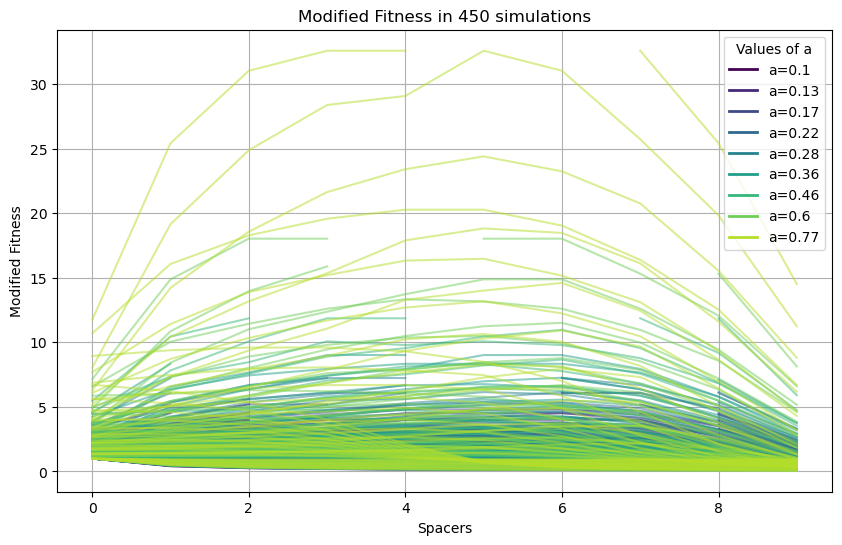

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import re

file_path = "ANALYSIS/fitness_modif_data.txt"
data_list = []

with open(file_path, "r") as f:
    current_params = None
    current_data = []

    for line in f:
        if line.startswith("#"):  # header
            if current_data:  
                data_list.append((*current_params, current_data))
                current_data = []
            
            match = re.search(r'a=(\d+\.\d+), pEndemic=(\d+\.\d+), g=(\d+\.\d+)', line)
            if match:
                current_params = tuple(map(float, match.groups()))
        else:
            try:
                current_data.append(float(line.strip())) 
            except ValueError:
                continue
    if current_data:
        data_list.append((*current_params, current_data))

df_list = []
for a, pEndemic, g, values in data_list:
    df_temp = pd.DataFrame({
        "fitness_modif": values,
        "a": [a] * len(values),
        "pEndemic": [pEndemic] * len(values),
        "g": [g] * len(values),
        "spacers": range(len(values)) 
    })
    df_list.append(df_temp)
df = pd.concat(df_list, ignore_index=True)

plt.figure(figsize=(10, 6))
colors = {a: plt.cm.viridis(i / len(df["a"].unique())) for i, a in enumerate(sorted(df["a"].unique()))}

for (a, pEndemic, g), group in df.groupby(["a", "pEndemic", "g"]):
    plt.plot(group["spacers"], group["fitness_modif"], color=colors[a], alpha=0.5)

legend_labels = [f"a={a}" for a in sorted(df['a'].unique())]
legend_patches = [plt.Line2D([0], [0], color=colors[a], lw=2) for a in sorted(df['a'].unique())]
plt.legend(legend_patches, legend_labels, title="Values of a", loc="best")

plt.xlabel("Spacers")
plt.ylabel("Modified Fitness")
plt.title("Modified Fitness in 450 simulations")
plt.grid(True)
plt.show()

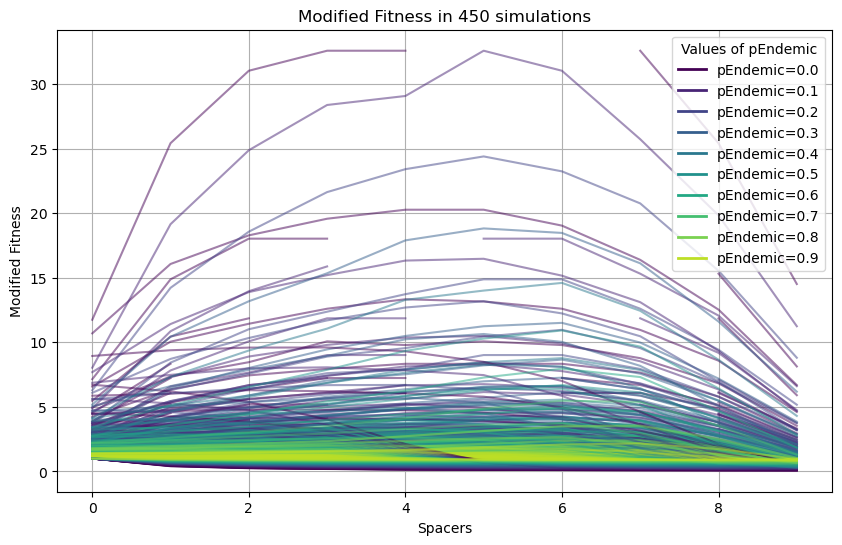

In [6]:
plt.figure(figsize=(10, 6))
colors = {pEndemic: plt.cm.viridis(i / len(df["pEndemic"].unique())) for i, pEndemic in enumerate(sorted(df["pEndemic"].unique()))}

for (a, pEndemic, g), group in df.groupby(["a", "pEndemic", "g"]):
    plt.plot(group["spacers"], group["fitness_modif"], color=colors[pEndemic], alpha=0.5)

legend_labels = [f"pEndemic={pEndemic}" for pEndemic in sorted(df['pEndemic'].unique())]
legend_patches = [plt.Line2D([0], [0], color=colors[a], lw=2) for a in sorted(df['pEndemic'].unique())]
plt.legend(legend_patches, legend_labels, title="Values of pEndemic", loc="best")

plt.xlabel("Spacers")
plt.ylabel("Modified Fitness")
plt.title("Modified Fitness in 450 simulations")
plt.grid(True)
plt.show()

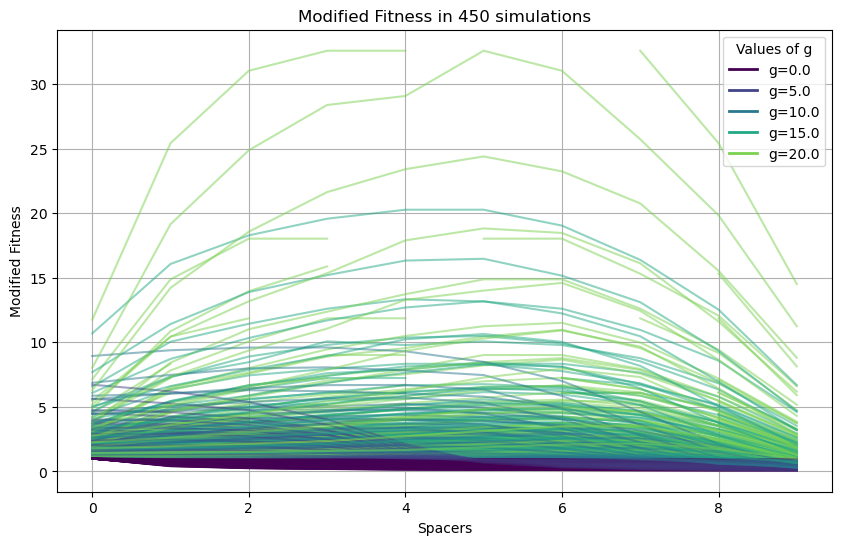

In [7]:
plt.figure(figsize=(10, 6))
colors = {g: plt.cm.viridis(i / len(df["g"].unique())) for i, g in enumerate(sorted(df["g"].unique()))}

for (a, pEndemic, g), group in df.groupby(["a", "pEndemic", "g"]):
    plt.plot(group["spacers"], group["fitness_modif"], color=colors[g], alpha=0.5)

legend_labels = [f"g={g}" for g in sorted(df['g'].unique())]
legend_patches = [plt.Line2D([0], [0], color=colors[g], lw=2) for g in sorted(df['g'].unique())]
plt.legend(legend_patches, legend_labels, title="Values of g", loc="best")

plt.xlabel("Spacers")
plt.ylabel("Modified Fitness")
plt.title("Modified Fitness in 450 simulations")
plt.grid(True)
plt.show()

### This graphs for the fitness without any modification

In [8]:
import glob
import pandas as pd
import re
import os
import numpy as np

output_file = "ANALYSIS/fitness_test_data.txt"
with open(output_file, "w") as f:
    for file_path in file_paths:
        data = load_file(file_path)
        fitness = data['fitness'].astype(float)
        file_name = os.path.basename(file_path)
        match = re.search(r'(\d+\.\d+)_(\d+\.\d+)_(\d+\.\d+)', file_name)
        
        if match:
            a, g, pEndemic = map(float, match.groups())
            f.write(f"# a={a}, pEndemic={pEndemic}, g={g}\n")
            fitness.to_csv(f, sep="\t", index=False, header=False)
            f.write("\n")

print(f"Results saved in {output_file}")

Results saved in ANALYSIS/fitness_test_data.txt


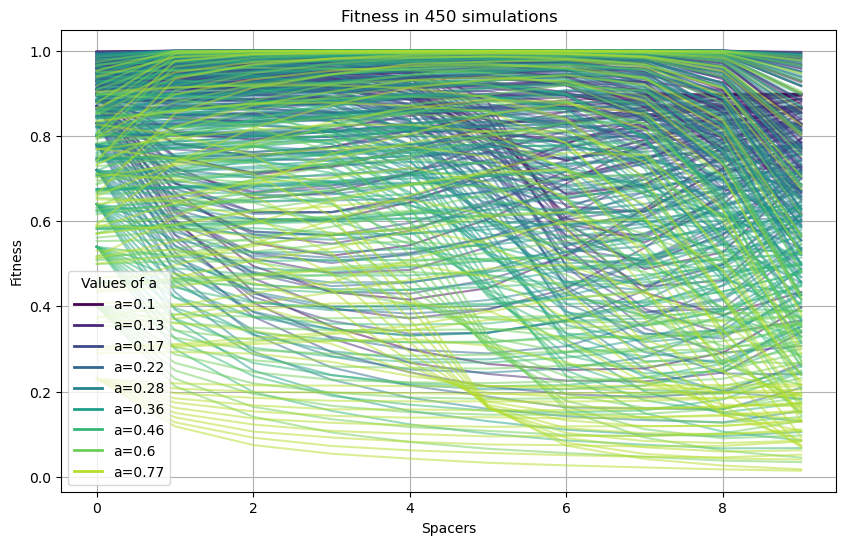

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import re

file_path = "ANALYSIS/fitness_test_data.txt"
data_list = []

with open(file_path, "r") as f:
    current_params = None
    current_data = []

    for line in f:
        if line.startswith("#"):  # header
            if current_data:  
                data_list.append((*current_params, current_data))
                current_data = []
            
            match = re.search(r'a=(\d+\.\d+), pEndemic=(\d+\.\d+), g=(\d+\.\d+)', line)
            if match:
                current_params = tuple(map(float, match.groups()))
        else:
            try:
                current_data.append(float(line.strip())) 
            except ValueError:
                continue
    if current_data:
        data_list.append((*current_params, current_data))

df_list = []
for a, pEndemic, g, values in data_list:
    df_temp = pd.DataFrame({
        "fitness_modif": values,
        "a": [a] * len(values),
        "pEndemic": [pEndemic] * len(values),
        "g": [g] * len(values),
        "spacers": range(len(values)) 
    })
    df_list.append(df_temp)
df = pd.concat(df_list, ignore_index=True)

plt.figure(figsize=(10, 6))
colors = {a: plt.cm.viridis(i / len(df["a"].unique())) for i, a in enumerate(sorted(df["a"].unique()))}

for (a, pEndemic, g), group in df.groupby(["a", "pEndemic", "g"]):
    plt.plot(group["spacers"], group["fitness_modif"], color=colors[a], alpha=0.5)

legend_labels = [f"a={a}" for a in sorted(df['a'].unique())]
legend_patches = [plt.Line2D([0], [0], color=colors[a], lw=2) for a in sorted(df['a'].unique())]
plt.legend(legend_patches, legend_labels, title="Values of a", loc="best")

plt.xlabel("Spacers")
plt.ylabel("Fitness")
plt.title("Fitness in 450 simulations")
plt.grid(True)
plt.show()

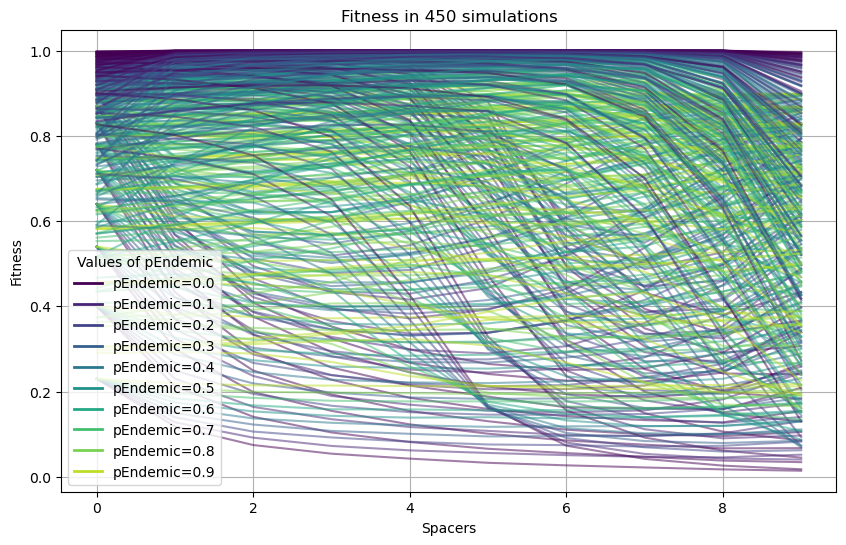

In [10]:
plt.figure(figsize=(10, 6))
colors = {pEndemic: plt.cm.viridis(i / len(df["pEndemic"].unique())) for i, pEndemic in enumerate(sorted(df["pEndemic"].unique()))}

for (a, pEndemic, g), group in df.groupby(["a", "pEndemic", "g"]):
    plt.plot(group["spacers"], group["fitness_modif"], color=colors[pEndemic], alpha=0.5)

legend_labels = [f"pEndemic={pEndemic}" for pEndemic in sorted(df['pEndemic'].unique())]
legend_patches = [plt.Line2D([0], [0], color=colors[a], lw=2) for a in sorted(df['pEndemic'].unique())]
plt.legend(legend_patches, legend_labels, title="Values of pEndemic", loc="best")

plt.xlabel("Spacers")
plt.ylabel("Fitness")
plt.title("Fitness in 450 simulations")
plt.grid(True)
plt.show()

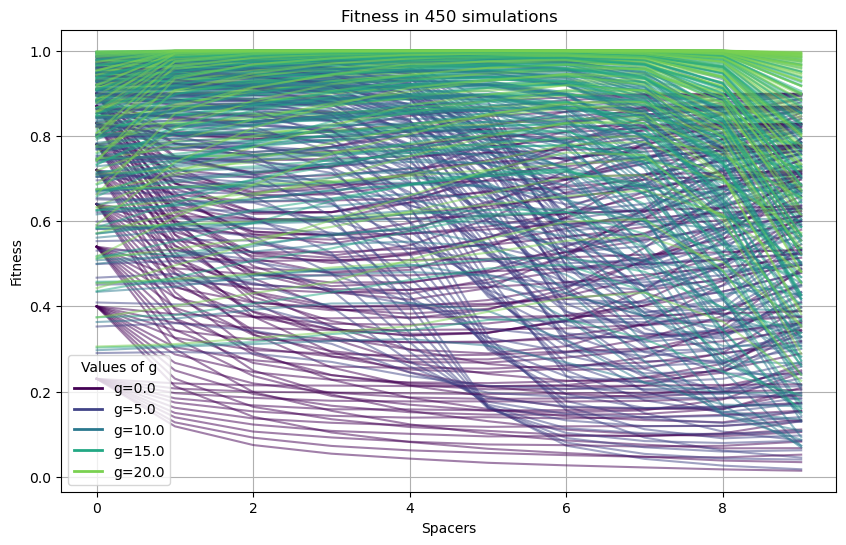

In [11]:
plt.figure(figsize=(10, 6))
colors = {g: plt.cm.viridis(i / len(df["g"].unique())) for i, g in enumerate(sorted(df["g"].unique()))}

for (a, pEndemic, g), group in df.groupby(["a", "pEndemic", "g"]):
    plt.plot(group["spacers"], group["fitness_modif"], color=colors[g], alpha=0.5)

legend_labels = [f"g={g}" for g in sorted(df['g'].unique())]
legend_patches = [plt.Line2D([0], [0], color=colors[g], lw=2) for g in sorted(df['g'].unique())]
plt.legend(legend_patches, legend_labels, title="Values of g", loc="best")

plt.xlabel("Spacers")
plt.ylabel("Fitness")
plt.title("Fitness in 450 simulations")
plt.grid(True)
plt.show()

## Different morphologies

### References
https://stackoverflow.com/questions/59163774/python-how-to-find-and-visually-mark-the-local-minima-of-a-sequence

https://www.w3schools.com/python/ref_math_dist.asp --> Euclidean distance between two points